In [2]:
import pandas as pd

In [3]:
df = pd.read_excel("../data/online Retail.xlsx")

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(5268)

## Data cleaning

### Create a clean dataframe

In [10]:
# Rows where descriprion is missing

df[df["Description"].isnull()].head()

# what the command means ---> shows the first records wheredescription is missing

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


In [11]:
# Rows where customerID is missing

df[df["CustomerID"].isnull()].head()

# what the command means ---> shows the first records where CustomerID is missing

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom


In [12]:
# To check cancelled inovoices

df[df["InvoiceNo"].astype(str).str.startswith("C")].head()

# Show me transactions whose invoice number starts with C.

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [13]:
# Negative transactions

df[df["Quantity"] < 0].head()

#This checks transactions where the quantity is negative.

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [14]:
# How many cancelled inovices do we have

df["InvoiceNo"].astype(str).str.startswith("C").sum()

# We are asking python "How many transactions have an InvoiceNo beginning with C?"

np.int64(9288)

In [15]:
(df["Quantity"] < 0).sum()

# This command asks "How many rows have a negative quantity?"

np.int64(10624)

In [16]:
(df["Quantity"] == 0).sum()

# This command asks "How many transactions have zero quantity?"

np.int64(0)

In [17]:
# Check basic price statistics

df["UnitPrice"].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [18]:
(df["UnitPrice"] == 0).sum()

# this command asks How many transactions have a UnitPrice of exactly 0?

np.int64(2515)

In [19]:
(df["UnitPrice"] < 0).sum()

# This command asks How many transactions have a negative price?

np.int64(2)

In [20]:
df[df["UnitPrice"] == 0].head()

# this command help us to see how zero price transactions look like

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


In [21]:
# find the duplicate rows

df[df.duplicated()].head()

# This shows us some of the duplicate records.

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


In [22]:
# REmove exact duplicate values

df_clean = df.drop_duplicates()

# Tell pandas Remove exact duplicate rows.and store cleaned dataframe in df_clean

In [23]:
df_clean.shape

# this shows new size of the dataframe after removing the duplicate values

(536641, 8)

In [24]:
df_clean.duplicated().sum()

# This verifies duplicate values are gone

np.int64(0)

In [25]:
df_clean.dtypes

# Checks our data types

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [26]:
df_clean["CustomerID"] = df_clean["CustomerID"].astype("Int64")

# this commad changes data type of customerID from float64 to Int64
# The Pandas Int64 type can handle missing values while still treating CustomerID as an integer.

df_clean.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID              Int64
Country                   str
dtype: object

In [27]:
# createing new column Revenue

df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# this command creat new column Revenuve and put the calculated value in side it

In [28]:
df_clean[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [29]:
df_clean["Revenue"].describe()

count    536641.000000
mean         18.123861
std         380.656263
min     -168469.600000
25%           3.750000
50%           9.870000
75%          17.400000
max      168469.600000
Name: Revenue, dtype: float64

In [30]:
# chech total revenue

df_clean["Revenue"].sum()

np.float64(9726006.954)

In [31]:
df_clean.shape

(536641, 9)

In [32]:
df_clean.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue'],
      dtype='str')

In [33]:
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
Revenue             0
dtype: int64

In [34]:
df_clean.duplicated().sum()

np.int64(0)

In [35]:
df_clean.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID              Int64
Country                   str
Revenue               float64
dtype: object

In [36]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [37]:
# save our cleaned dataset

df_clean.to_csv("../data/cleaned_sales.csv", index=False)

# EDA ---> Exploratory Data Analysis

In [38]:
# loade the cleaned dataset

import pandas as pd
df = pd.read_csv("../data/cleaned_sales.csv")

# why we are loading again
# Because our cleaning stage produce the dinal file : Raw Excel --> Cleaning --> Cleaned_sales.csv --> EDA
# This means our EDA is based on the final cleaned dataset, not on the original raw data.

## Now we see weather our cleaned dataset looks correct

In [39]:
df.shape

(536641, 9)

In [40]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue'],
      dtype='str')

In [41]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
Revenue        float64
dtype: object

In [42]:
df.describe()

# This shows us statistical summary

,Quantity,UnitPrice,CustomerID,Revenue
count,536641.000000,536641.000000,401604.000000,536641.000000
mean,9.620029,4.632656,15281.160818,18.123861
std,219.130156,97.233118,1714.006089,380.656263
min,-80995.000000,-11062.060000,12346.000000,-168469.600000
25%,1.000000,1.250000,13939.000000,3.750000
50%,3.000000,2.080000,15145.000000,9.870000
75%,10.000000,4.130000,16784.000000,17.400000
max,80995.000000,38970.000000,18287.000000,168469.600000


In [43]:
df.nunique()

# count unique values

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
Revenue         5998
dtype: int64

# Business KPIs

In [44]:
# Total revenue

total_revenue = df["Revenue"].sum()
# add all the revenue from all transactions
total_revenue

np.float64(9726006.954)

In [45]:
# total orders

total_orders = df["InvoiceNo"].nunique()
total_orders

25900

In [46]:
# Total quantity sold

total_quantity = df["Quantity"].sum()
total_quantity

# This adds the quantity from all transactions.

np.int64(5162502)

In [47]:
# Total products

total_products = df["StockCode"].nunique()
total_products

# How many different products exist in the dataset? 

4070

In [48]:
# Total customers

total_customers = df["CustomerID"].nunique()
total_customers

# This counts  unique customers because a customer can purchase many products

4372

In [49]:
# Total countries

total_countries = df["Country"].nunique()
total_countries

# This tells us how many different countries appear in the dataset.

38

In [132]:
# Business KPIs
# Now put all KPI's togeather isted of running six saperate outputs every time

kpis = {
    "Total Revenue": total_revenue,
    "Total orders": total_orders,
    "Total Quantity": total_quantity,
    "Total Products": total_products,
    "Total Customers": total_customers,
    "Total Countries": total_countries
}
kpis

{'Total Revenue': np.float64(9726006.954),
 'Total orders': 25900,
 'Total Quantity': np.int64(5162502),
 'Total Products': 4070,
 'Total Customers': 4372,
 'Total Countries': 38}

# Sales & Revenue Analysis

In [51]:
df["Revenue"].describe()

count    536641.000000
mean         18.123861
std         380.656263
min     -168469.600000
25%           3.750000
50%           9.870000
75%          17.400000
max      168469.600000
Name: Revenue, dtype: float64

In [52]:
# Average Revenue per Transaction Row

average_transaction_value = df["Revenue"].mean()
average_transaction_value

np.float64(18.1238611175814)

In [53]:
# Find the higest Revenue Transactions

df.sort_values("Revenue", ascending = False).head(10)

# this shows the 10 transaction lines with the higest revenue

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
535160,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60
61006,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60
220825,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,38970.00
14757,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,13541.33
297645,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,11062.06
171873,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,8142.75
345627,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450.0,United Kingdom,7144.72
159101,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom,6539.40
52169,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,6539.40
418088,573003,23084,RABBIT NIGHT LIGHT,2400,2011-10-27 12:11:00,2.08,14646.0,Netherlands,4992.00


In [54]:
# Find the Lowest Revenue Transactions

df.sort_values("Revenue", ascending = True).head(10)

# This shows 10 transaction values with lowest revenue
# You see negative Revenue here.
#That's expected because returns/cancellations can produce negative quantities.

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
535161,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom,-168469.60
61011,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,-77183.60
220826,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.00,15098.0,United Kingdom,-38970.00
519497,C580605,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:36:00,17836.46,NaN,United Kingdom,-17836.46
43193,C540117,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:55:00,16888.02,NaN,United Kingdom,-16888.02
43194,C540118,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:57:00,16453.71,NaN,United Kingdom,-16453.71
16087,C537651,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:49:00,13541.33,NaN,United Kingdom,-13541.33
14756,C537630,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:04:00,13541.33,NaN,United Kingdom,-13541.33
15972,C537644,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:34:00,13474.79,NaN,United Kingdom,-13474.79
519496,C580604,AMAZONFEE,AMAZON FEE,-1,2011-12-05 11:35:00,11586.50,NaN,United Kingdom,-11586.50


In [55]:
# Calculate Average Order value(aov)

aov = df["Revenue"].sum() / df["InvoiceNo"].nunique()  # or aov = total_revenue / total_orders 
aov

np.float64(375.521504015444)

In [56]:
# Creat a sales summary

sales_summary = {
    "Total Revenue": total_revenue,
    "Total Orders": total_orders,
    "Average Order Value": aov,
    "Total Quantity": total_quantity
}
sales_summary

{'Total Revenue': np.float64(9726006.954),
 'Total Orders': 25900,
 'Average Order Value': np.float64(375.521504015444),
 'Total Quantity': np.int64(5162502)}

# Time-Series Analysis

In [57]:
df["InvoiceDate"].dtype

<StringDtype(storage='python', na_value=nan)>

In [58]:
# Convert invoiceDate  to datetime

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# now the invoicedate datatype will change from string to datetime
df["InvoiceDate"].dtype

dtype('<M8[us]')

In [59]:
# Find the date range

df["InvoiceDate"].min

<bound method Series.min of 0        2010-12-01 08:26:00
1        2010-12-01 08:26:00
2        2010-12-01 08:26:00
3        2010-12-01 08:26:00
4        2010-12-01 08:26:00
                 ...        
536636   2011-12-09 12:50:00
536637   2011-12-09 12:50:00
536638   2011-12-09 12:50:00
536639   2011-12-09 12:50:00
536640   2011-12-09 12:50:00
Name: InvoiceDate, Length: 536641, dtype: datetime64[us]>

In [60]:
# Creat year and month columns
df["year"] = df["InvoiceDate"].dt.year
# this extracts the year

df["Month"] = df["InvoiceDate"].dt.month
# this extracts month

In [61]:
# Check the new columns

df[["InvoiceDate", "year", "Month"]].head()

,InvoiceDate,year,Month
0,2010-12-01 08:26:00,2010,12
1,2010-12-01 08:26:00,2010,12
2,2010-12-01 08:26:00,2010,12
3,2010-12-01 08:26:00,2010,12
4,2010-12-01 08:26:00,2010,12


In [62]:
# Monthly revenue

monthly_revenue = df.groupby(["year", "Month"])["Revenue"].sum()
monthly_revenue

year  Month
2010  12        746723.610
2011  1         558448.560
      2         497026.410
      3         682013.980
      4         492367.841
      5         722094.100
      6         689977.230
      7         680156.991
      8         681386.460
      9        1017596.682
      10       1069368.230
      11       1456145.800
      12        432701.060
Name: Revenue, dtype: float64

In [63]:
# Find the best sales month

monthly_revenue.sort_values(ascending = False).head()
# This gives us the 5 highest-revenue months.

year  Month
2011  11       1456145.800
      10       1069368.230
      9        1017596.682
2010  12        746723.610
2011  5         722094.100
Name: Revenue, dtype: float64

In [64]:
monthly_revenue.sort_values(ascending = True).head()
# This gives us the 5 lowest-revenue months.

year  Month
2011  12       432701.060
      4        492367.841
      2        497026.410
      1        558448.560
      7        680156.991
Name: Revenue, dtype: float64

# Product Analysis

In [65]:
# Top products by Quantity sold

product_quantity = df.groupby("StockCode")["Quantity"].sum()
product_quantity

StockCode
10002           1037
10080            495
10120            192
10123C           -13
10123G           -38
                ... 
gift_0001_20      20
gift_0001_30      37
gift_0001_40       3
gift_0001_50       4
m                  1
Name: Quantity, Length: 4070, dtype: int64

In [66]:
# Find the top 10 products by quantity

product_quantity.sort_values(ascending = False).head(10)
# This gives us the 10 products with the highest quantity sold.

StockCode
22197     56427
84077     53751
85099B    47260
85123A    38811
84879     36122
21212     36016
23084     30597
22492     26437
22616     26299
21977     24719
Name: Quantity, dtype: int64

In [67]:
# Find top products by revenue

product_revenue = df.groupby("StockCode")["Revenue"].sum()
product_revenue


StockCode
10002           759.89
10080           119.09
10120            40.32
10123C            3.25
10123G            0.00
                 ...  
gift_0001_20    167.05
gift_0001_30    175.53
gift_0001_40    100.70
gift_0001_50    167.56
m                 2.55
Name: Revenue, Length: 4070, dtype: float64

In [68]:
product_revenue.sort_values(ascending = False).head(10)
# This gives us the top 10 products by revenue.

StockCode
DOT       206245.48
22423     164459.49
47566      98243.88
85123A     97838.45
85099B     92175.79
23084      66661.63
POST       66230.64
22086      63715.24
84879      58792.42
79321      53746.66
Name: Revenue, dtype: float64

In [69]:
# Product names insted of product codes

product_summary = df.groupby(["StockCode", "Description"]).agg(
    Total_Quantity = ("Quantity", "sum"), 
    Total_Revenue = ("Revenue", "sum")
).reset_index()

product_summary

# We are saying "For each product, claculate total quantity and total revenue

,StockCode,Description,Total_Quantity,Total_Revenue
0,10002,INFLATABLE POLITICAL GLOBE,860,759.89
1,10080,GROOVY CACTUS INFLATABLE,303,119.09
2,10080,check,22,0.00
3,10120,DOGGY RUBBER,192,40.32
4,10123C,HEARTS WRAPPING TAPE,5,3.25
...,...,...,...,...
4787,gift_0001_20,to push order througha s stock was,10,0.00
4788,gift_0001_30,Dotcomgiftshop Gift Voucher £30.00,7,175.53
4789,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00,3,100.70
4790,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00,4,167.56


In [70]:
# Top 10 products by revenue

product_summary.sort_values(
    "Total_Revenue",
    ascending = False
).head(10)

,StockCode,Description,Total_Quantity,Total_Revenue
4780,DOT,DOTCOM POSTAGE,707,206245.48
1554,22423,REGENCY CAKESTAND 3 TIER,13007,164459.49
3295,47566,PARTY BUNTING,18010,98243.88
4223,85123A,WHITE HANGING HEART T-LIGHT HOLDER,35006,97659.94
4197,85099B,JUMBO BAG RED RETROSPOT,47260,92175.79
2344,23084,RABBIT NIGHT LIGHT,30631,66661.63
4783,POST,POSTAGE,3003,66230.64
1207,22086,PAPER CHAIN KIT 50'S CHRISTMAS,18876,63715.24
3956,84879,ASSORTED COLOUR BIRD ORNAMENT,36282,58792.42
3525,79321,CHILLI LIGHTS,10225,53746.66


In [71]:
# Top 10 products by quantity


product_summary.sort_values("Total_Quantity", ascending = False).head(10)

,StockCode,Description,Total_Quantity,Total_Revenue
3617,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,53751,13560.09
4197,85099B,JUMBO BAG RED RETROSPOT,47260,92175.79
1333,22197,POPCORN HOLDER,36322,33959.26
3956,84879,ASSORTED COLOUR BIRD ORNAMENT,36282,58792.42
531,21212,PACK OF 72 RETROSPOT CAKE CASES,36016,21047.07
4223,85123A,WHITE HANGING HEART T-LIGHT HOLDER,35006,97659.94
2344,23084,RABBIT NIGHT LIGHT,30631,66661.63
1630,22492,MINI PAINT SET VINTAGE,26437,16810.42
1775,22616,PACK OF 12 LONDON TISSUES,26299,7967.82
1122,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24719,12170.77


# Country Analysis

In [72]:
# Check countries

df["Country"].nunique()

# nunique() ----> tells us how amny diffrent countries
# unique() -----> shows us which countries

38

In [73]:
# Revenue by country

country_revenue = df.groupby("Country")["Revenue"].sum()
country_revenue

# Shows us Country   Revenue

Country
Australia                137009.770
Austria                   10154.320
Bahrain                     548.400
Belgium                   40910.960
Brazil                     1143.600
Canada                     3666.380
Channel Islands           20076.390
Cyprus                    12858.760
Czech Republic              707.720
Denmark                   18768.140
EIRE                     262993.380
European Community         1291.750
Finland                   22326.740
France                   197317.110
Germany                  221509.470
Greece                     4710.520
Hong Kong                  9908.240
Iceland                    4310.000
Israel                     7901.970
Italy                     16890.510
Japan                     35340.620
Lebanon                    1693.880
Lithuania                  1661.060
Malta                      2505.470
Netherlands              284661.540
Norway                    35163.460
Poland                     7213.140
Portugal            

In [74]:
# Top 10 countries by revenue

country_revenue.sort_values(ascending = False).head(10)

Country
United Kingdom    8167128.184
Netherlands        284661.540
EIRE               262993.380
Germany            221509.470
France             197317.110
Australia          137009.770
Switzerland         56363.050
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: Revenue, dtype: float64

In [75]:
# Lowest Revenue Countries

country_revenue.sort_values(ascending = True).head(10)

Country
Saudi Arabia             131.17
Bahrain                  548.40
Czech Republic           707.72
RSA                     1002.31
Brazil                  1143.60
European Community      1291.75
Lithuania               1661.06
Lebanon                 1693.88
USA                     1730.92
United Arab Emirates    1902.28
Name: Revenue, dtype: float64

In [76]:
# Quantity sold by coutry

country_quantity = df.groupby("Country")["Quantity"].sum()
country_quantity

# This shows country     Quantity

Country
Australia                 83643
Austria                    4827
Bahrain                     260
Belgium                   23152
Brazil                      356
Canada                     2763
Channel Islands            9473
Cyprus                     6296
Czech Republic              592
Denmark                    8188
EIRE                     142495
European Community          497
Finland                   10666
France                   110438
Germany                  117341
Greece                     1556
Hong Kong                  4709
Iceland                    2458
Israel                     4350
Italy                      7999
Japan                     25218
Lebanon                     386
Lithuania                   652
Malta                       944
Netherlands              200128
Norway                    19247
Poland                     3653
Portugal                  16153
RSA                         352
Saudi Arabia                 75
Singapore                  5234


In [77]:
# Quantity sold by country

country_quantity.sort_values(ascending = False).head(10)
# show top 10 countries by quatity sold

Country
United Kingdom    4250328
Netherlands        200128
EIRE               142495
Germany            117341
France             110438
Australia           83643
Sweden              35632
Switzerland         30313
Spain               26817
Japan               25218
Name: Quantity, dtype: int64

In [78]:
country_quantity.sort_values(ascending = True).head(10)
# show bottom 10 countries by quantity sold

Country
Saudi Arabia             75
Bahrain                 260
RSA                     352
Brazil                  356
Lebanon                 386
European Community      497
Czech Republic          592
Lithuania               652
Malta                   944
United Arab Emirates    982
Name: Quantity, dtype: int64

In [79]:
# Customers by Country

country_customers = df.groupby("Country")["CustomerID"].nunique()
country_customers

# This shows country   customers

Country
Australia                  9
Austria                   11
Bahrain                    2
Belgium                   25
Brazil                     1
Canada                     4
Channel Islands            9
Cyprus                     8
Czech Republic             1
Denmark                    9
EIRE                       3
European Community         1
Finland                   12
France                    87
Germany                   95
Greece                     4
Hong Kong                  0
Iceland                    1
Israel                     4
Italy                     15
Japan                      8
Lebanon                    1
Lithuania                  1
Malta                      2
Netherlands                9
Norway                    10
Poland                     6
Portugal                  19
RSA                        1
Saudi Arabia               1
Singapore                  1
Spain                     31
Sweden                     8
Switzerland               21
USA   

In [80]:
country_customers.sort_values(ascending = False).head(10)

Country
United Kingdom    3950
Germany             95
France              87
Spain               31
Belgium             25
Switzerland         21
Portugal            19
Italy               15
Finland             12
Austria             11
Name: CustomerID, dtype: int64

In [81]:
country_customers.sort_values(ascending = True).head(10)

Country
Hong Kong             0
Brazil                1
European Community    1
Czech Republic        1
Lebanon               1
Lithuania             1
Iceland               1
Singapore             1
RSA                   1
Saudi Arabia          1
Name: CustomerID, dtype: int64

In [82]:
# Creat a country summary

country_summary = df.groupby("Country").agg(
    Total_Revenue = ("Revenue", "sum"),
    Total_Quantity = ("Quantity", "sum"),
    Total_Customers = ("CustomerID", "nunique"),
    Total_Orders = ("InvoiceNo", "nunique")
).reset_index()

In [83]:
country_summary.sort_values("Total_Revenue", ascending = False).head(10)

,Country,Total_Revenue,Total_Quantity,Total_Customers,Total_Orders
36,United Kingdom,8167128.184,4250328,3950,23494
24,Netherlands,284661.540,200128,9,101
10,EIRE,262993.380,142495,3,360
14,Germany,221509.470,117341,95,603
13,France,197317.110,110438,87,461
0,Australia,137009.770,83643,9,69
33,Switzerland,56363.050,30313,21,74
31,Spain,54756.030,26817,31,105
3,Belgium,40910.960,23152,25,119
32,Sweden,36585.410,35632,8,46


# Customer Analysis

In [84]:
# Number of customers 

total_customers = df["CustomerID"].nunique()
total_customers

# nunique() how many unique customers exist

4372

In [85]:
# Revenue by customer

customer_revenue = df.groupby("CustomerID")["Revenue"].sum()
customer_revenue.head()

# this shows customer    revenue

CustomerID
12346.0       0.00
12347.0    4310.00
12348.0    1797.24
12349.0    1757.55
12350.0     334.40
Name: Revenue, dtype: float64

In [86]:
# Top 10 customers by revenue

customer_revenue.sort_values(ascending = False).head(10)

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
14156.0    113214.59
17511.0     88125.38
16684.0     65892.08
13694.0     62690.54
15311.0     59284.19
Name: Revenue, dtype: float64

In [87]:
# Number of orders per customers

customer_orders = df.groupby("CustomerID")["InvoiceNo"].nunique()
customer_orders

CustomerID
12346.0     2
12347.0     7
12348.0     4
12349.0     1
12350.0     1
           ..
18280.0     1
18281.0     1
18282.0     3
18283.0    16
18287.0     3
Name: InvoiceNo, Length: 4372, dtype: int64

In [88]:
# Top 10 customers who place most orders

customer_orders.sort_values(ascending = False).head(10)

CustomerID
14911.0    248
12748.0    224
17841.0    169
14606.0    128
15311.0    118
13089.0    118
12971.0     89
14527.0     86
13408.0     81
14646.0     77
Name: InvoiceNo, dtype: int64

In [89]:
# Quantity purchased by customer

customer_quantity = df.groupby("CustomerID")["Quantity"].sum()
customer_quantity

CustomerID
12346.0       0
12347.0    2458
12348.0    2341
12349.0     631
12350.0     197
           ... 
18280.0      45
18281.0      54
18282.0      98
18283.0    1357
18287.0    1586
Name: Quantity, Length: 4372, dtype: int64

In [90]:
# which customer purchased higest quantity

customer_quantity.sort_values(ascending = False).head(10)

CustomerID
14646.0    196719
12415.0     77242
14911.0     77155
17450.0     69009
18102.0     64122
17511.0     63012
13694.0     61899
14298.0     58021
14156.0     56908
16684.0     49390
Name: Quantity, dtype: int64

In [91]:
# customer summary

customer_summary = df.groupby("CustomerID").agg(
    Total_Revenue = ("Revenue","sum"),
    Total_Quantity = ("Quantity","sum"),
    Total_Orders = ("InvoiceNo", "nunique")
).reset_index()

customer_summary.head(10)

,CustomerID,Total_Revenue,Total_Quantity,Total_Orders
0,12346.0,0.00,0,2
1,12347.0,4310.00,2458,7
2,12348.0,1797.24,2341,4
3,12349.0,1757.55,631,1
4,12350.0,334.40,197,1
5,12352.0,1545.41,470,11
6,12353.0,89.00,20,1
7,12354.0,1079.40,530,1
8,12355.0,459.40,240,1
9,12356.0,2811.43,1591,3


In [92]:
# Top 10 valuable customers

customer_summary.sort_values("Total_Revenue", ascending = False).head(10)

,CustomerID,Total_Revenue,Total_Quantity,Total_Orders
1703,14646.0,279489.02,196719,77
4233,18102.0,256438.49,64122,62
3758,17450.0,187322.17,69009,55
1895,14911.0,132458.73,77155,248
55,12415.0,123725.45,77242,26
1345,14156.0,113214.59,56908,66
3801,17511.0,88125.38,63012,46
3202,16684.0,65892.08,49390,31
1005,13694.0,62690.54,61899,60
2192,15311.0,59284.19,37673,118


In [93]:
# Average Revenue per customer

average_customer_revenue = (customer_summary["Total_Revenue"].mean())
average_customer_revenue

np.float64(1893.5314327538886)

# Return and Cancellation Analysis

In [94]:
# IDentify cancelled orders

cancelled_orders = df[df["InvoiceNo"].astype(str).str.startswith("C")]
# in this data set the cancelled orders have an InvoiceNo starts with c so this comman helps us to show the cancelled invoice/orders

cancelled_orders.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,year,Month
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50,2010,12
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65,2010,12
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80,2010,12
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,2010,12
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96,2010,12


In [95]:
# Count cancelled orders

cancelled_order_count = cancelled_orders["InvoiceNo"].nunique()
cancelled_order_count

3836

In [96]:
# Revenue from Cancelled Transaction

cancelled_revenue = cancelled_orders["Revenue"].sum()
cancelled_revenue

np.float64(-893979.73)

In [97]:
# Total returned Quantity

returned_quantity = cancelled_orders["Quantity"].abs().sum()
# abs() ---> mwans conver negative numbers into positive. returns are often represented as positive numbers

returned_quantity

np.int64(275560)

In [98]:
# Return revenue value 

returned_value = cancelled_orders["Revenue"].abs().sum()
returned_value

np.float64(893979.73)

In [99]:
# product with higest returns

returned_products = cancelled_orders.groupby("Description")["Quantity"].sum().abs()
returned_products

Description
 50'S CHRISTMAS GIFT BAG LARGE       2
 DOLLY GIRL BEAKER                   7
 OVAL WALL MIRROR DIAMANTE           5
 SET 2 TEA TOWELS I LOVE LONDON      8
 SPACEBOY BABY GIFT SET              6
                                    ..
ZINC SWEETHEART WIRE LETTER RACK     4
ZINC T-LIGHT HOLDER STAR LARGE      11
ZINC T-LIGHT HOLDER STARS SMALL     44
ZINC TOP  2 DOOR WOODEN SHELF        5
ZINC WILLIE WINKIE  CANDLE STICK    12
Name: Quantity, Length: 1972, dtype: int64

In [100]:
returned_products.sort_values(ascending = False).head(10)
# This gives us the top 10 products by returned quantity.

Description
PAPER CRAFT , LITTLE BIRDIE            80995
MEDIUM CERAMIC TOP STORAGE JAR         74494
ROTATING SILVER ANGELS T-LIGHT HLDR     9376
Manual                                  4066
FAIRY CAKE FLANNEL ASSORTED COLOUR      3150
WHITE HANGING HEART T-LIGHT HOLDER      2578
GIN + TONIC DIET METAL SIGN             2030
HERB MARKER BASIL                       1527
FELTCRAFT DOLL MOLLY                    1447
TEA TIME PARTY BUNTING                  1424
Name: Quantity, dtype: int64

In [101]:
# Returns by country
# Now we see Which countries have the highest number of returned units?

returns_by_country = cancelled_orders.groupby("Country")["Quantity"].sum().abs()
returns_by_country

Country
Australia                556
Austria                   54
Bahrain                   54
Belgium                   85
Channel Islands           12
Cyprus                    44
Czech Republic            79
Denmark                   47
EIRE                    4786
European Community         2
Finland                   38
France                  1623
Germany                 1815
Greece                     1
Hong Kong                  4
Israel                    56
Italy                    113
Japan                    798
Malta                     26
Netherlands              809
Norway                    91
Poland                    31
Portugal                  78
Saudi Arabia               5
Singapore                  7
Spain                   1127
Sweden                   446
Switzerland              305
USA                     1424
United Kingdom        261044
Name: Quantity, dtype: int64

In [102]:
returns_by_country.sort_values(ascending = False).head(10)
# This gives the top 10 countries by returned quantity.

Country
United Kingdom    261044
EIRE                4786
Germany             1815
France              1623
USA                 1424
Spain               1127
Netherlands          809
Japan                798
Australia            556
Sweden               446
Name: Quantity, dtype: int64

In [103]:
# Cancellation/Return Rate
# Return Rate = (cancelled orders/Total orders) x 100

total_orders = df["InvoiceNo"].nunique()

return_rate = (cancelled_order_count / total_orders) * 100
# This gives the percentage of unique invoice numbers that are cancellation invoices.

return_rate

14.810810810810812

In [104]:
# Cancellation summary

cancellation_summary = {
    "Total Orders": total_orders,
    "Cancelled Ordres": cancelled_order_count,
    "Cancelled Revenue": cancelled_revenue,
    "Returned Quantity": returned_quantity,
    "Returned Value": returned_value,
    "Cancellation Rate (%)": return_rate
}
cancellation_summary

{'Total Orders': 25900,
 'Cancelled Ordres': 3836,
 'Cancelled Revenue': np.float64(-893979.73),
 'Returned Quantity': np.int64(275560),
 'Returned Value': np.float64(893979.73),
 'Cancellation Rate (%)': 14.810810810810812}

# Data Visualization

In [105]:
import matplotlib.pyplot as plt
# Matplotlib ---> Used for creating basic and highly customizable charts.

import seaborn as sns
# Built on top of Matplotlib and makes statistical/business charts easier to create.

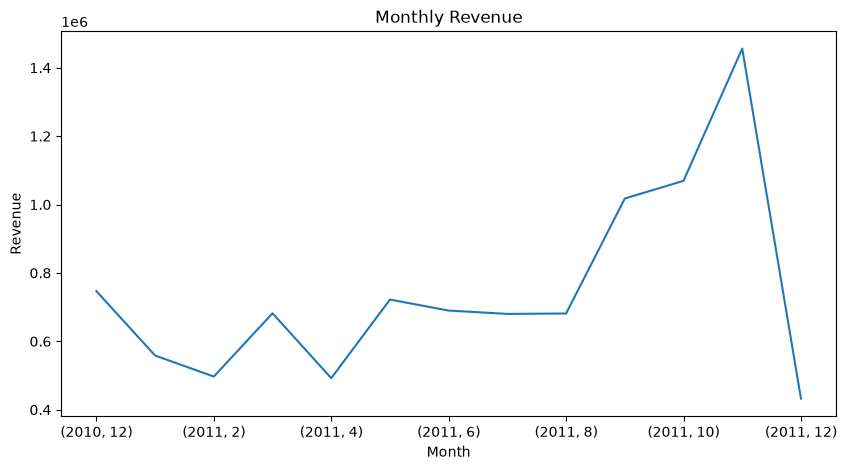

In [106]:
# Monthly Revenue Trend
# Monthly revenue line chart

monthly_revenue = df.groupby(["year", "Month"])["Revenue"].sum()

# Now lets visualize it
monthly_revenue.plot(kind = "line", figsize = (10,5))
# monthly_revenu.plot ----> create a chart from data
# kind = line ----> create a line chart
# figsize = (10,5) ----> Make the chart 10 inches wide and 5 inches tall.

plt.title("Monthly Revenue") # --> adds the chart title
plt.xlabel("Month") # --> Labels the x axis
plt.ylabel("Revenue") # --> lables the y axis
plt.show() # ---> display the chart

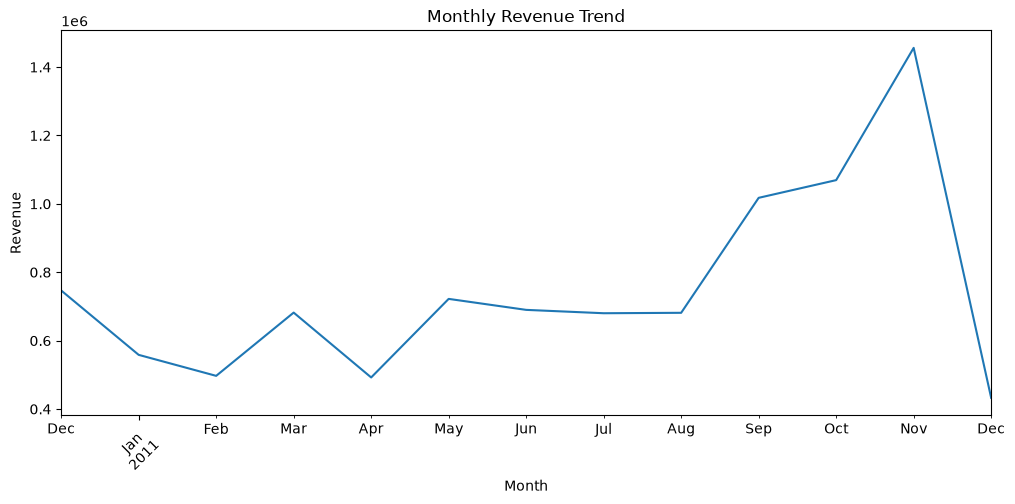

In [107]:
# Monthly Revenue Trend
# For a cleaner chart, let's create a proper monthly column.

df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")
# This converts dates into ------> 2010-12  2011-01  2011-02 ......

monthly_sales = df.groupby("YearMonth")["Revenue"].sum()

monthly_sales.plot(kind = "line", figsize = (12,5))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45) # makes the month labels easier to read.
plt.show()

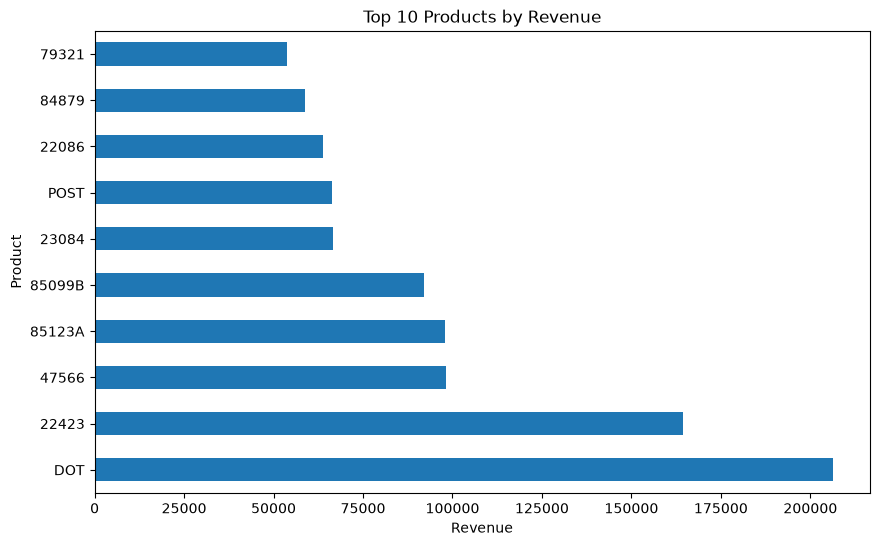

In [108]:
# Top products by revenue

product_revenue = df.groupby("StockCode")["Revenue"].sum()
top_products = product_revenue.sort_values(ascending = False).head(10)

top_products.plot(kind = "barh", figsize = (10,6)) # ---> barh means horizontal bar garaph
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

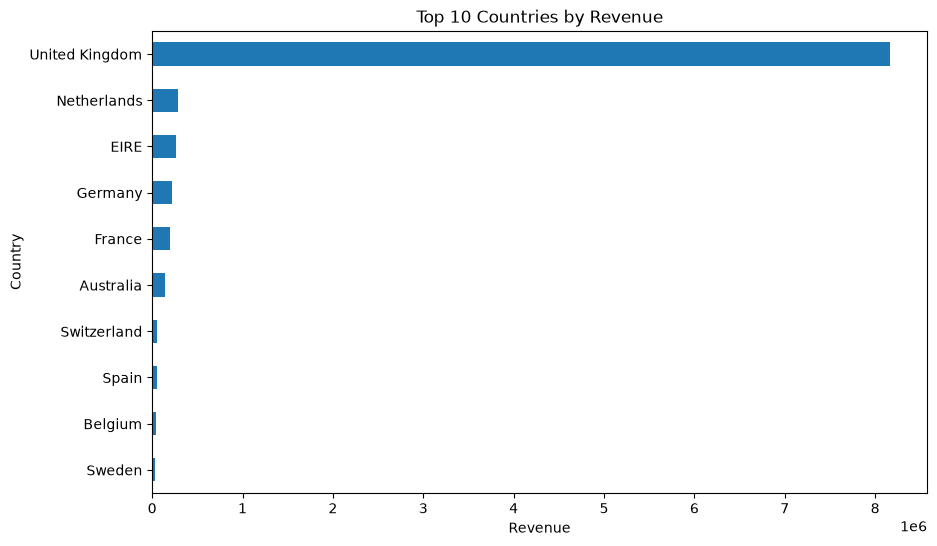

In [109]:
# Top countries by Revenue 

top_countries = df.groupby("Country")["Revenue"].sum().sort_values(ascending = False).head(10)

top_countries.sort_values().plot(kind = "barh", figsize = (10,6))
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()

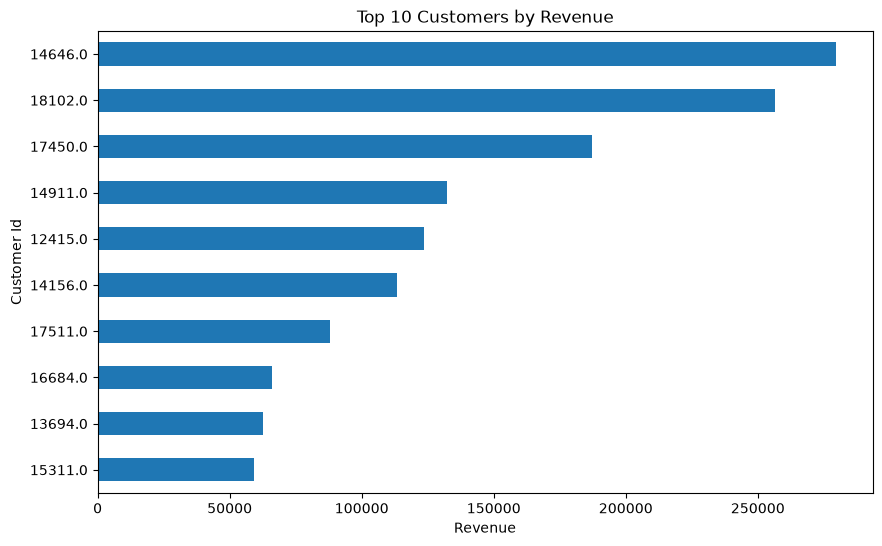

In [110]:
# Top customers by revenue

customer_revenue
top_customers = customer_revenue.sort_values(ascending = False).head(10)

top_customers.sort_values().plot(kind = "barh", figsize = (10,6))
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer Id")
plt.show()

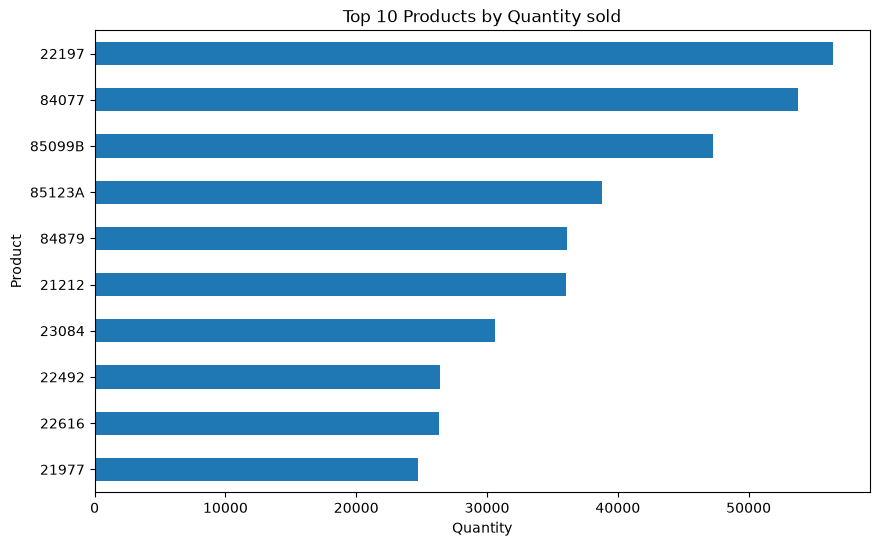

In [111]:
# Top products BY Quantity

top_quantity_products = df.groupby("StockCode")["Quantity"].sum().sort_values(ascending = False).head(10)
top_quantity_products.sort_values().plot(kind = "barh", figsize = (10,6))

plt.title("Top 10 Products by Quantity sold")
plt.xlabel("Quantity")
plt.ylabel("Product")
plt.show()                                                                                

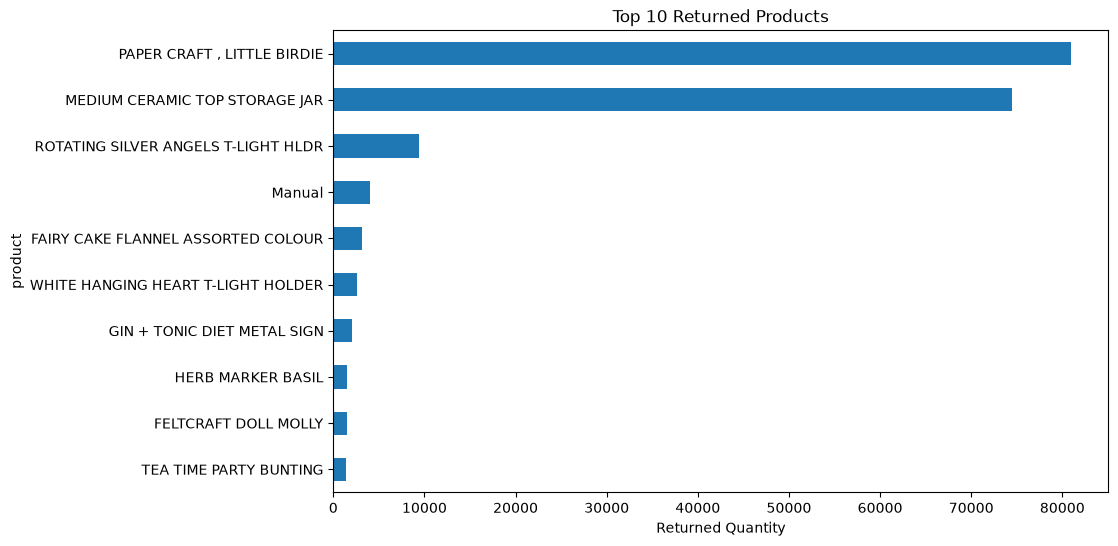

In [112]:
# Top returned products
returned_products
returned_products.sort_values(ascending = False).head(10).sort_values().plot(kind = "barh", figsize = (10,6))

plt.title("Top 10 Returned Products")
plt.xlabel("Returned Quantity")
plt.ylabel("product")
plt.show()

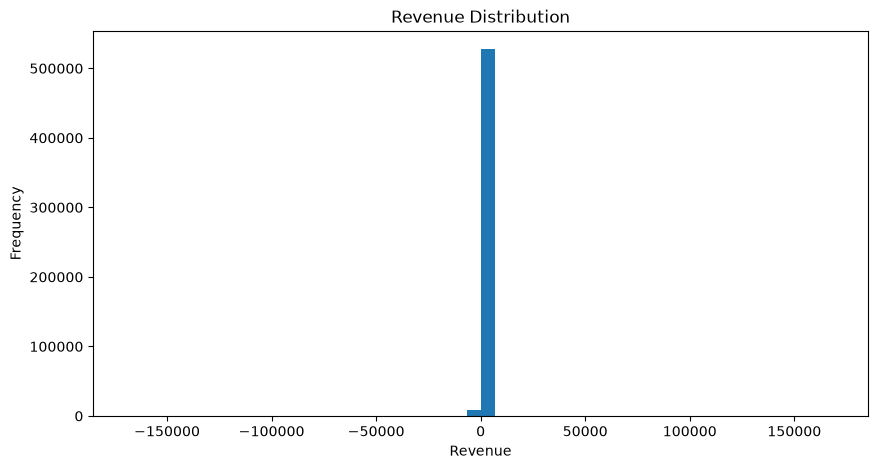

In [113]:
# Revenue distributions

plt.figure(figsize = (10,5))
plt.hist(df["Revenue"], bins = 50) 
# A histogram shows how frequently diffrent ranges of value occurs
# This help us to understand the distribution of transaction revenue

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

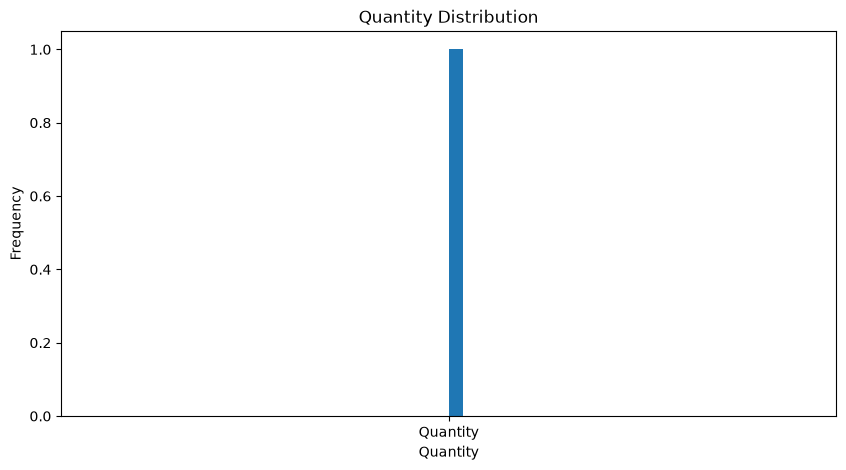

In [114]:
# Quantity Distribution

plt.figure(figsize = (10,5))
plt.hist(["Quantity"], bins = 50)
# This helps us understand how many items are typically purchased per transaction line.

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()


# Business Insights


## 1. Overall Business Performance

In [115]:
# Let see all our main KPIs togeather

total_revenue = df["Revenue"].sum()
total_orders = df["InvoiceNo"].nunique()
total_quantity = df["Quantity"].sum()
total_products = df["StockCode"].nunique()
total_customers = df["CustomerID"].nunique()
total_countries = df["Country"].nunique()

overall_summary = {
    "Total Revenue": total_revenue,
    "Total Orders": total_orders,
    "Total Quantity Sold": total_quantity,
    "Total Products": total_products,
    "Total Customers": total_customers,
    "Total Countries": total_countries
}

overall_summary

# We're bringing our important business numbers into one place.

{'Total Revenue': np.float64(9726006.954),
 'Total Orders': 25900,
 'Total Quantity Sold': np.int64(5162502),
 'Total Products': 4070,
 'Total Customers': 4372,
 'Total Countries': 38}

## 2. MONTHLY REVENUE INSIGHT

In [116]:
monthly_sales

YearMonth
2010-12     746723.610
2011-01     558448.560
2011-02     497026.410
2011-03     682013.980
2011-04     492367.841
2011-05     722094.100
2011-06     689977.230
2011-07     680156.991
2011-08     681386.460
2011-09    1017596.682
2011-10    1069368.230
2011-11    1456145.800
2011-12     432701.060
Freq: M, Name: Revenue, dtype: float64

In [117]:
monthly_sales.sort_values(ascending = False).head()

YearMonth
2011-11    1456145.800
2011-10    1069368.230
2011-09    1017596.682
2010-12     746723.610
2011-05     722094.100
Freq: M, Name: Revenue, dtype: float64

In [118]:
# To find only the best month

best_month = monthly_sales.idxmax()      # Give me the label/index where the maximum value occurs.
best_month_revenue = monthly_sales.max()  # Give me the largest value.

best_month, best_month_revenue  # month with higest reveneue, revenue generated during that month

(Period('2011-11', 'M'), np.float64(1456145.8))

### Monthly Revenue Insight

The highest revenue was generated in November 2011, with revenue of 1,456,145.8.

This period represents the strongest sales performance in the dataset and can be useful for future sales, inventory, and marketing planning.


## 3. PRODUCT PERFORMANCE INSIGHT 

In [122]:
top_product_insights = product_summary.sort_values("Total_Revenue",  ascending = False).head(10)
top_product_insights

,StockCode,Description,Total_Quantity,Total_Revenue
4780,DOT,DOTCOM POSTAGE,707,206245.48
1554,22423,REGENCY CAKESTAND 3 TIER,13007,164459.49
3295,47566,PARTY BUNTING,18010,98243.88
4223,85123A,WHITE HANGING HEART T-LIGHT HOLDER,35006,97659.94
4197,85099B,JUMBO BAG RED RETROSPOT,47260,92175.79
2344,23084,RABBIT NIGHT LIGHT,30631,66661.63
4783,POST,POSTAGE,3003,66230.64
1207,22086,PAPER CHAIN KIT 50'S CHRISTMAS,18876,63715.24
3956,84879,ASSORTED COLOUR BIRD ORNAMENT,36282,58792.42
3525,79321,CHILLI LIGHTS,10225,53746.66


In [123]:
# single Higest-Revenue product

best_product = top_product_insights.iloc[0]
# .iloc[0] means Select data based on its position.
best_product

StockCode                    DOT
Description       DOTCOM POSTAGE
Total_Quantity               707
Total_Revenue          206245.48
Name: 4780, dtype: object

In [124]:
top_quantity_products = df.groupby(
    ["StockCode", "Description"]
)["Quantity"].sum().sort_values(
    ascending=False
).head(10)

top_quantity_products

# Which products have the highest total quantity sold?

StockCode  Description                       
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
85099B     JUMBO BAG RED RETROSPOT               47260
22197      POPCORN HOLDER                        36322
84879      ASSORTED COLOUR BIRD ORNAMENT         36282
21212      PACK OF 72 RETROSPOT CAKE CASES       36016
85123A     WHITE HANGING HEART T-LIGHT HOLDER    35006
23084      RABBIT NIGHT LIGHT                    30631
22492      MINI PAINT SET VINTAGE                26437
22616      PACK OF 12 LONDON TISSUES             26299
21977      PACK OF 60 PINK PAISLEY CAKE CASES    24719
Name: Quantity, dtype: int64

### Product Performance Insight

The analysis identified the top-performing products based on total revenue and quantity sold.

The highest-revenue products are important contributors to overall sales and should receive appropriate inventory and marketing attention.

Product performance was evaluated using both revenue and quantity because a product with high sales volume does not necessarily generate the highest revenue.


## 4. COUNTRY PERFORMANCE INSIGHT

In [125]:
top_country_insights = country_summary.sort_values("Total_Revenue", ascending = False).head(10)
top_country_insights

,Country,Total_Revenue,Total_Quantity,Total_Customers,Total_Orders
36,United Kingdom,8167128.184,4250328,3950,23494
24,Netherlands,284661.540,200128,9,101
10,EIRE,262993.380,142495,3,360
14,Germany,221509.470,117341,95,603
13,France,197317.110,110438,87,461
0,Australia,137009.770,83643,9,69
33,Switzerland,56363.050,30313,21,74
31,Spain,54756.030,26817,31,105
3,Belgium,40910.960,23152,25,119
32,Sweden,36585.410,35632,8,46


In [126]:
# Look at the Top 10 Countries More Clearly

top_country_insights[
    [
        "Country",
        "Total_Revenue",
        "Total_Quantity",
        "Total_Customers",
        "Total_Orders"
    ]
]

,Country,Total_Revenue,Total_Quantity,Total_Customers,Total_Orders
36,United Kingdom,8167128.184,4250328,3950,23494
24,Netherlands,284661.540,200128,9,101
10,EIRE,262993.380,142495,3,360
14,Germany,221509.470,117341,95,603
13,France,197317.110,110438,87,461
0,Australia,137009.770,83643,9,69
33,Switzerland,56363.050,30313,21,74
31,Spain,54756.030,26817,31,105
3,Belgium,40910.960,23152,25,119
32,Sweden,36585.410,35632,8,46


In [127]:
best_country = top_country_insights.iloc[0]
best_country

Country            United Kingdom
Total_Revenue         8167128.184
Total_Quantity            4250328
Total_Customers              3950
Total_Orders                23494
Name: 36, dtype: object

### Country Performance Insight

The top-performing countries were identified based on total revenue.
These markets represent important sources of business revenue and can be prioritized for future marketing and sales activities.


## 5. Customer Performance

In [128]:
top_customer_insights = customer_summary.sort_values("Total_Revenue", ascending = False).head(10)
top_customer_insights

,CustomerID,Total_Revenue,Total_Quantity,Total_Orders
1703,14646.0,279489.02,196719,77
4233,18102.0,256438.49,64122,62
3758,17450.0,187322.17,69009,55
1895,14911.0,132458.73,77155,248
55,12415.0,123725.45,77242,26
1345,14156.0,113214.59,56908,66
3801,17511.0,88125.38,63012,46
3202,16684.0,65892.08,49390,31
1005,13694.0,62690.54,61899,60
2192,15311.0,59284.19,37673,118


In [129]:
best_customer = top_customer_insights.iloc[0]
best_customer

CustomerID         14646.00
Total_Revenue     279489.02
Total_Quantity    196719.00
Total_Orders          77.00
Name: 1703, dtype: float64

### Customer Performance Insight

A small group of high-value customers contributes significantly to the overall revenue.
These customers can be targeted with loyalty programs, personalized offers, and retention strategies.

## 6. Return & Cancellation Insight

In [130]:
cancellation_summary

{'Total Orders': 25900,
 'Cancelled Ordres': 3836,
 'Cancelled Revenue': np.float64(-893979.73),
 'Returned Quantity': np.int64(275560),
 'Returned Value': np.float64(893979.73),
 'Cancellation Rate (%)': 14.810810810810812}

In [131]:
# Find products with higest returns

returned_products.sort_values(
    ascending=False
).head(10)

Description
PAPER CRAFT , LITTLE BIRDIE            80995
MEDIUM CERAMIC TOP STORAGE JAR         74494
ROTATING SILVER ANGELS T-LIGHT HLDR     9376
Manual                                  4066
FAIRY CAKE FLANNEL ASSORTED COLOUR      3150
WHITE HANGING HEART T-LIGHT HOLDER      2578
GIN + TONIC DIET METAL SIGN             2030
HERB MARKER BASIL                       1527
FELTCRAFT DOLL MOLLY                    1447
TEA TIME PARTY BUNTING                  1424
Name: Quantity, dtype: int64

### Return & Cancellation Insight

The analysis identified products and transactions with higher cancellation and return activity.
These products should be investigated further to understand potential operational, product, packaging, or delivery issues.

## 7. Final Business Recommendations

### Business Recommendations

1. Focus on high-value customers
   - Identify customers generating the highest revenue.
   - Use loyalty programs and personalized offers to encourage repeat purchases.

2. Prepare for peak sales periods
   - Use monthly revenue trends to identify high-performing periods.
   - Plan inventory and marketing activities before peak demand.

3. Focus on high-performing products
   - Maintain sufficient inventory for products generating significant revenue.
   - Consider promoting successful products through targeted campaigns.

4. Focus on high-performing markets
   - Identify countries contributing the most revenue.
   - Prioritize marketing and sales strategies in these markets.

5. Investigate high-return products
   - Identify products with unusually high return activity.
   - Investigate potential product, packaging, delivery, or operational issues.

## 8. Final Project Summary

# Final Business Summary

This analysis examined e-commerce transaction data to understand overall sales performance, customer behavior, product performance, country-level performance, and return activity.

The analysis identified key revenue-generating products, customers, countries, and sales periods. It also highlighted cancellation and return activity that may require further investigation.

These findings can help the business improve inventory planning, customer retention, marketing strategies, and operational decision-making.

In [213]:
import pandas as pd

# Load the cleaned CSV
df_import = pd.read_csv("../data/cleaned_sales.csv")

# Remove any duplicate column names
df_import = df_import.loc[:, ~df_import.columns.duplicated()]

# Keep only the columns needed for MySQL
required_columns = [
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    "CustomerID",
    "Country",
    "Revenue"
]

df_import = df_import[required_columns]

# Save a fresh CSV for MySQL
df_import.to_csv(
    "../data/cleaned_sales_mysql.csv",
    index=False
)

print("New MySQL CSV created successfully!")
print(df_import.columns.tolist())
print(df_import.shape)

New MySQL CSV created successfully!
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue']
(536641, 9)


In [216]:
import pandas as pd

df_check = pd.read_csv("../data/cleaned_sales_mysql.csv")

print(df_check.columns.tolist())
print("Number of columns:", len(df_check.columns))
print("Duplicate columns:")
print(df_check.columns[df_check.columns.duplicated()].tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue']
Number of columns: 9
Duplicate columns:
[]


In [217]:
import os
print(os.path.abspath("../data/cleaned_sales_mysql.csv"))

D:\Desktop\E-Commerce-Sales-Customer-Analytics\data\cleaned_sales_mysql.csv


In [1]:
pip install mysql-connector-python

   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
    --------------------------------------- 0.3/17.7 MB ? eta -:--:--
   -- ------------------------------------- 1.0/17.7 MB 4.3 MB/s eta 0:00:04
   ---- ----------------------------------- 2.1/17.7 MB 4.2 MB/s eta 0:00:04
   ------ --------------------------------- 2.9/17.7 MB 4.4 MB/s eta 0:00:04
   -------- ------------------------------- 3.7/17.7 MB 4.0 MB/s eta 0:00:04
   ----------- ---------------------------- 5.2/17.7 MB 4.6 MB/s eta 0:00:03
   -------------- ------------------------- 6.6/17.7 MB 4.9 MB/s eta 0:00:03
   ------------------ --------------------- 8.1/17.7 MB 5.2 MB/s eta 0:00:02
   ---------------------- ----------------- 10.0/17.7 MB 5.6 MB/s eta 0:00:02
   ------------------------- -------------- 11.3/17.7 MB 5.7 MB/s eta 0:00:02
   ----------------------------- ---------- 13.1/17.7 MB 6.0 MB/s eta 0:00:01
   -------------------------------- ------- 14.2/17.7 MB 6.1 MB/s eta 0:00:01
   ------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import mysql.connector

print("MySQL connector is working!")

MySQL connector is working!


In [3]:
import mysql.connector

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Sethu@1810",
    database="ecommerce_analysis"
)

print("Connected to MySQL successfully!")

Connected to MySQL successfully!


In [4]:
cursor = connection.cursor()

cursor.execute("SELECT DATABASE();")

result = cursor.fetchone()

print("Connected database:", result[0])

Connected database: ecommerce_analysis


In [5]:
import pandas as pd

csv_path = "../data/cleaned_sales_mysql.csv"

df_mysql = pd.read_csv(csv_path)

print("CSV loaded successfully!")
print("Rows:", len(df_mysql))
print("Columns:", len(df_mysql.columns))
print(df_mysql.columns.tolist())

CSV loaded successfully!
Rows: 536641
Columns: 9
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue']


In [6]:
# SQL statement for inserting one row
insert_query = """
INSERT INTO sales
(InvoiceNo, StockCode, Description, Quantity, InvoiceDate,
 UnitPrice, CustomerID, Country, Revenue)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

# Convert DataFrame to tuples
data = list(df_mysql.itertuples(index=False, name=None))

# Insert in batches
batch_size = 5000

for start in range(0, len(data), batch_size):
    batch = data[start:start + batch_size]
    cursor.executemany(insert_query, batch)
    connection.commit()
    
    print(f"Inserted {min(start + batch_size, len(data))} / {len(data)} rows")

print("🎉 All data imported successfully!")

ProgrammingError: 1054 (42S22): Unknown column 'nan' in 'field list'

In [ ]:
import pandas as pd

df_mysql = pd.read_csv("../data/cleaned_sales_mysql.csv")

# Convert InvoiceDate to proper datetime
df_mysql["InvoiceDate"] = pd.to_datetime(df_mysql["InvoiceDate"])

# Convert CustomerID blanks to SQL NULL
df_mysql["CustomerID"] = df_mysql["CustomerID"].apply(
    lambda x: None if pd.isna(x) else str(int(x))
)

# Convert Description blanks to SQL NULL
df_mysql["Description"] = df_mysql["Description"].apply(
    lambda x: None if pd.isna(x) else str(x)
)

print("Data prepared successfully!")
print("Rows:", len(df_mysql))
print("Columns:", len(df_mysql.columns))
print("Missing CustomerID:", df_mysql["CustomerID"].isna().sum())
print("Missing Description:", df_mysql["Description"].isna().sum())

In [1]:
import pandas as pd

df_mysql = pd.read_csv("../data/cleaned_sales_mysql.csv")

print("CSV loaded successfully!")
print("Rows:", len(df_mysql))
print("Columns:", len(df_mysql.columns))
print(df_mysql.columns.tolist())

CSV loaded successfully!
Rows: 536641
Columns: 9
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue']


In [2]:
# Convert missing CustomerID values to None
df_mysql["CustomerID"] = df_mysql["CustomerID"].apply(
    lambda x: None if pd.isna(x) else str(int(x))
)

# Convert missing Description values to None
df_mysql["Description"] = df_mysql["Description"].apply(
    lambda x: None if pd.isna(x) else str(x)
)

print("Data prepared successfully!")
print("Rows:", len(df_mysql))
print("Columns:", len(df_mysql.columns))
print("Missing CustomerID:", df_mysql["CustomerID"].isna().sum())
print("Missing Description:", df_mysql["Description"].isna().sum())

Data prepared successfully!
Rows: 536641
Columns: 9
Missing CustomerID: 135037
Missing Description: 1454


In [4]:
import mysql.connector

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Sethu@1810",
    database="ecommerce_analysis"
)

print("Connected to MySQL successfully!")

Connected to MySQL successfully!


In [5]:
cursor = connection.cursor()

cursor.execute("SELECT COUNT(*) FROM sales")

result = cursor.fetchone()

print("Rows currently in MySQL:", result[0])

Rows currently in MySQL: 0


In [6]:
insert_query = """
INSERT INTO sales
(
    InvoiceNo,
    StockCode,
    Description,
    Quantity,
    InvoiceDate,
    UnitPrice,
    CustomerID,
    Country,
    Revenue
)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

batch_size = 1000
total_rows = len(df_mysql)

print("Starting MySQL import...")
print("Total rows to import:", total_rows)

for start in range(0, total_rows, batch_size):

    # Make sure the connection is still active
    if not connection.is_connected():
        connection.reconnect(attempts=3, delay=2)

    batch_df = df_mysql.iloc[start:start + batch_size]

    batch = [
        tuple(row)
        for row in batch_df.itertuples(index=False, name=None)
    ]

    cursor.executemany(insert_query, batch)
    connection.commit()

    inserted = min(start + batch_size, total_rows)

    print(f"Inserted {inserted:,} / {total_rows:,} rows")

print("🎉 MySQL import completed successfully!")

Starting MySQL import...
Total rows to import: 536641


ProgrammingError: 1054 (42S22): Unknown column 'nan' in 'field list'

In [7]:
df_mysql.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
Revenue             0
dtype: int64

In [9]:
# Convert columns to object type first
df_mysql["Description"] = df_mysql["Description"].astype(object)
df_mysql["CustomerID"] = df_mysql["CustomerID"].astype(object)

# Replace NaN with Python None
df_mysql["Description"] = df_mysql["Description"].where(
    df_mysql["Description"].notna(),
    None
)

df_mysql["CustomerID"] = df_mysql["CustomerID"].where(
    df_mysql["CustomerID"].notna(),
    None
)

print("Missing values converted to SQL NULL format!")

Missing values converted to SQL NULL format!


In [12]:
df_mysql.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
Revenue             0
dtype: int64

In [13]:
import math

customer_nan = sum(
    isinstance(x, float) and math.isnan(x)
    for x in df_mysql["CustomerID"]
)

description_nan = sum(
    isinstance(x, float) and math.isnan(x)
    for x in df_mysql["Description"]
)

customer_none = sum(
    x is None
    for x in df_mysql["CustomerID"]
)

description_none = sum(
    x is None
    for x in df_mysql["Description"]
)

print("CustomerID actual NaN:", customer_nan)
print("CustomerID Python None:", customer_none)

print("Description actual NaN:", description_nan)
print("Description Python None:", description_none)

CustomerID actual NaN: 0
CustomerID Python None: 135037
Description actual NaN: 0
Description Python None: 1454


In [14]:
import pandas as pd

# Reload the CSV fresh
df_mysql = pd.read_csv("../data/cleaned_sales_mysql.csv")

# Convert date column
df_mysql["InvoiceDate"] = pd.to_datetime(df_mysql["InvoiceDate"])

print("Data loaded and date converted!")
print("Rows:", len(df_mysql))

Data loaded and date converted!
Rows: 536641


In [15]:
insert_query = """
INSERT INTO sales
(
    InvoiceNo,
    StockCode,
    Description,
    Quantity,
    InvoiceDate,
    UnitPrice,
    CustomerID,
    Country,
    Revenue
)
VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

batch_size = 1000
total_rows = len(df_mysql)

print("Ready for MySQL import!")
print("Total rows:", total_rows)

Ready for MySQL import!
Total rows: 536641


In [16]:
import pandas as pd

for start in range(0, total_rows, batch_size):

    # Check connection
    if not connection.is_connected():
        connection.reconnect(attempts=3, delay=2)

    batch_df = df_mysql.iloc[start:start + batch_size]

    batch = []

    for row in batch_df.itertuples(index=False, name=None):

        # Convert every pandas NaN/NaT to Python None
        clean_row = tuple(
            None if pd.isna(value) else value
            for value in row
        )

        batch.append(clean_row)

    cursor.executemany(insert_query, batch)
    connection.commit()

    inserted = min(start + batch_size, total_rows)

    print(f"Inserted {inserted:,} / {total_rows:,} rows")

print("🎉 MySQL import completed successfully!")

Inserted 1,000 / 536,641 rows
Inserted 2,000 / 536,641 rows
Inserted 3,000 / 536,641 rows
Inserted 4,000 / 536,641 rows
Inserted 5,000 / 536,641 rows
Inserted 6,000 / 536,641 rows
Inserted 7,000 / 536,641 rows
Inserted 8,000 / 536,641 rows
Inserted 9,000 / 536,641 rows
Inserted 10,000 / 536,641 rows
Inserted 11,000 / 536,641 rows
Inserted 12,000 / 536,641 rows
Inserted 13,000 / 536,641 rows
Inserted 14,000 / 536,641 rows
Inserted 15,000 / 536,641 rows
Inserted 16,000 / 536,641 rows
Inserted 17,000 / 536,641 rows
Inserted 18,000 / 536,641 rows
Inserted 19,000 / 536,641 rows
Inserted 20,000 / 536,641 rows
Inserted 21,000 / 536,641 rows
Inserted 22,000 / 536,641 rows
Inserted 23,000 / 536,641 rows
Inserted 24,000 / 536,641 rows
Inserted 25,000 / 536,641 rows
Inserted 26,000 / 536,641 rows
Inserted 27,000 / 536,641 rows
Inserted 28,000 / 536,641 rows
Inserted 29,000 / 536,641 rows
Inserted 30,000 / 536,641 rows
Inserted 31,000 / 536,641 rows
Inserted 32,000 / 536,641 rows
Inserted 33,000 /